# Predict the Introverts from the Extroverts | Classification

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


# Preprocessing
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

In [2]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s5e7/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s5e7/test.csv")

In [3]:
print(train.shape)
print(test.shape)

(18524, 9)
(6175, 8)


In [4]:
train.isnull().sum()

id                              0
Time_spent_Alone             1190
Stage_fear                   1893
Social_event_attendance      1180
Going_outside                1466
Drained_after_socializing    1149
Friends_circle_size          1054
Post_frequency               1264
Personality                     0
dtype: int64

In [5]:
test.isnull().sum()

id                             0
Time_spent_Alone             425
Stage_fear                   598
Social_event_attendance      397
Going_outside                466
Drained_after_socializing    432
Friends_circle_size          350
Post_frequency               408
dtype: int64

In [6]:
df=pd.concat([train,test]) 

### EDA

In [7]:
df.head()

,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24699 entries, 0 to 6174
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         24699 non-null  int64  
 1   Time_spent_Alone           23084 non-null  float64
 2   Stage_fear                 22208 non-null  object 
 3   Social_event_attendance    23122 non-null  float64
 4   Going_outside              22767 non-null  float64
 5   Drained_after_socializing  23118 non-null  object 
 6   Friends_circle_size        23295 non-null  float64
 7   Post_frequency             23027 non-null  float64
 8   Personality                18524 non-null  object 
dtypes: float64(5), int64(1), object(3)
memory usage: 1.9+ MB


In [9]:
df.isnull().sum()

id                              0
Time_spent_Alone             1615
Stage_fear                   2491
Social_event_attendance      1577
Going_outside                1932
Drained_after_socializing    1581
Friends_circle_size          1404
Post_frequency               1672
Personality                  6175
dtype: int64

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,24699.0,12349.000000,7130.131485,0.0,6174.5,12349.0,18523.5,24698.0
Time_spent_Alone,23084.0,3.132559,2.999230,0.0,1.0,2.0,4.0,11.0
Social_event_attendance,23122.0,5.270824,2.754491,0.0,3.0,5.0,8.0,10.0
Going_outside,22767.0,4.042693,2.058194,0.0,3.0,4.0,6.0,7.0
Friends_circle_size,23295.0,7.999657,4.215721,0.0,5.0,8.0,12.0,15.0
Post_frequency,23027.0,4.993833,2.876184,0.0,3.0,5.0,7.0,10.0


### Data Processing & Feature Engineering

In [11]:
df["Stage_fear"].value_counts() 

Stage_fear
No     16845
Yes     5363
Name: count, dtype: int64

In [12]:
df["Stage_fear"].fillna(df["Stage_fear"].mode()[0], inplace=True)

df["Stage_fear"] = df["Stage_fear"].map({"Yes": 1, "No": 0})

In [13]:
df["Drained_after_socializing"].value_counts()

Drained_after_socializing
No     17750
Yes     5368
Name: count, dtype: int64

In [14]:
df["Drained_after_socializing"].fillna(df["Drained_after_socializing"].mode()[0], inplace=True)

df["Drained_after_socializing"] = df["Drained_after_socializing"].map({"Yes": 1, "No": 0})

In [15]:
df["Personality"] = df["Personality"].map({"Extrovert": 1, "Introvert": 0})

In [16]:
df.isnull().sum()

id                              0
Time_spent_Alone             1615
Stage_fear                      0
Social_event_attendance      1577
Going_outside                1932
Drained_after_socializing       0
Friends_circle_size          1404
Post_frequency               1672
Personality                  6175
dtype: int64

In [17]:
#Fill the MISSING VALUES (KNN Method)
cols = df.columns.drop(["Personality", "id"])

# KNN Imputer (n_neighbors=5 komşunun ortalamasını alır)
knn_imputer = KNNImputer(n_neighbors=5)
df[cols] = knn_imputer.fit_transform(df[cols])

In [18]:
df.isnull().sum()

id                              0
Time_spent_Alone                0
Stage_fear                      0
Social_event_attendance         0
Going_outside                   0
Drained_after_socializing       0
Friends_circle_size             0
Post_frequency                  0
Personality                  6175
dtype: int64

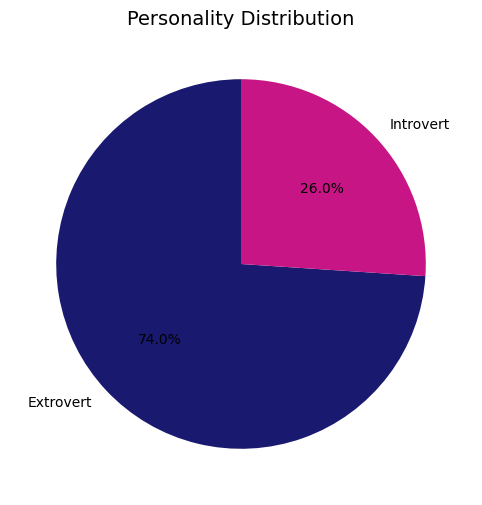

In [19]:
#Personality
plt.figure(figsize=(8, 6))
personality_counts = df['Personality'].value_counts()
colors = ['MidnightBlue', 'MediumVioletRed']
plt.pie(personality_counts.values, labels=['Extrovert', 'Introvert'], 
        autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Personality Distribution', fontsize=14)
plt.show()

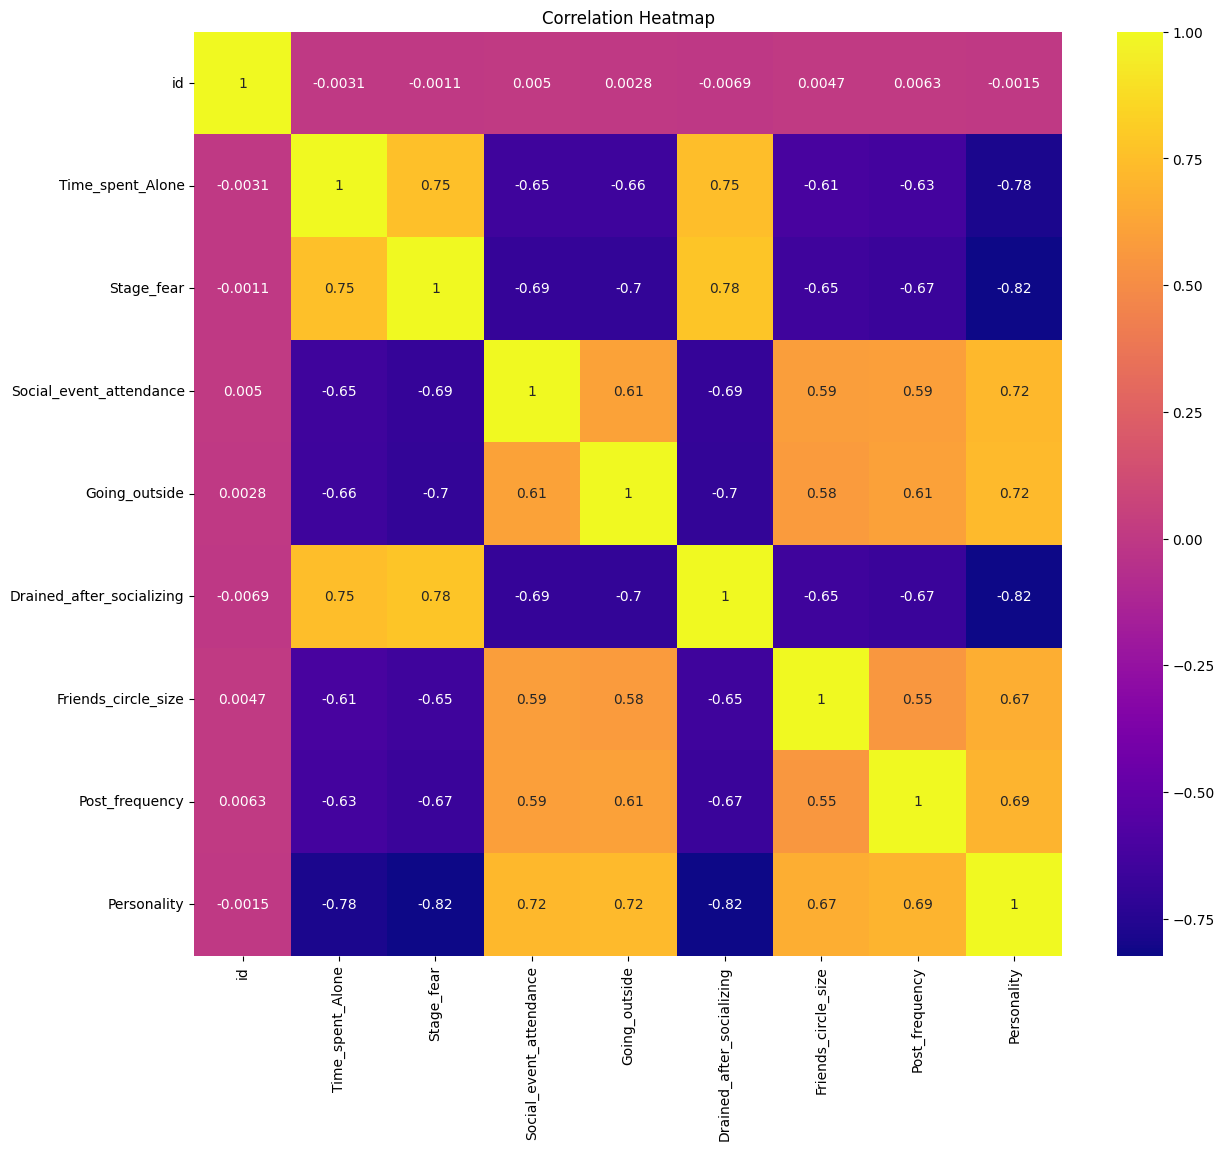

In [20]:
#Correlation Heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='plasma')
plt.title('Correlation Heatmap')
plt.show()

In [21]:
df['Introversion_Score'] = (
    df['Time_spent_Alone'] * 0.3 +  # Yalnız zaman
    (10 - df['Social_event_attendance']) * 0.3 +  # Sosyal etkinliğe katılmama
    df['Stage_fear'] * 5 +  # Sahne korkusu (1 veya 0)
    df['Drained_after_socializing'] * 5  # Sosyal faaliyetten tükenme
)

In [22]:
df['Social_Engagement'] = (
    df['Social_event_attendance'] +
    df['Going_outside'] +
    df['Friends_circle_size'] / 2 +  
    df['Post_frequency']
) / 4

In [23]:
df['Social_Comfort'] = (
    df['Social_event_attendance'] +
    df['Going_outside'] +
    (1 - df['Stage_fear']) * 5 +
    (1 - df['Drained_after_socializing']) * 5
) / 4

In [24]:
abs(df.corr(numeric_only=True))['Personality'].sort_values(ascending=False)

Personality                  1.000000
Introversion_Score           0.886192
Social_Comfort               0.873101
Social_Engagement            0.841187
Drained_after_socializing    0.822843
Stage_fear                   0.816959
Time_spent_Alone             0.780826
Going_outside                0.724199
Social_event_attendance      0.717045
Post_frequency               0.693884
Friends_circle_size          0.668919
id                           0.001475
Name: Personality, dtype: float64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24699 entries, 0 to 6174
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         24699 non-null  int64  
 1   Time_spent_Alone           24699 non-null  float64
 2   Stage_fear                 24699 non-null  float64
 3   Social_event_attendance    24699 non-null  float64
 4   Going_outside              24699 non-null  float64
 5   Drained_after_socializing  24699 non-null  float64
 6   Friends_circle_size        24699 non-null  float64
 7   Post_frequency             24699 non-null  float64
 8   Personality                18524 non-null  float64
 9   Introversion_Score         24699 non-null  float64
 10  Social_Engagement          24699 non-null  float64
 11  Social_Comfort             24699 non-null  float64
dtypes: float64(11), int64(1)
memory usage: 2.4 MB


In [26]:
train = df[df['Personality'].notna()]
test  = df[df['Personality'].isna()]

In [27]:
train.shape

(18524, 12)

In [28]:
x = train.drop(["Personality", "id"], axis=1)
y = train['Personality']

In [29]:
x_final_test = test.drop(["Personality", "id"], axis=1)

In [30]:
def algo_test(x, y):
    modeller = [
        BernoulliNB(),
        LogisticRegression(max_iter=500, solver='lbfgs'),   
        DecisionTreeClassifier(),
        RandomForestClassifier(),
        GradientBoostingClassifier(),
        KNeighborsClassifier(),
        AdaBoostClassifier(),
        MultinomialNB(),
        XGBClassifier(use_label_encoder=False, eval_metric='logloss', verbosity=0, random_state=42),
        LGBMClassifier(verbose=-1, random_state=42),
        CatBoostClassifier(verbose=0, random_state=42)
    ]
    isimler = [
        "BernoulliNB", 
        "LogisticRegression", 
        "DecisionTreeClassifier", 
        "RandomForestClassifier", 
        "GradientBoostingClassifier", 
        "KNeighborsClassifier", 
        "AdaBoostClassifier", 
        "MultinomialNB",
        "XGBClassifier",
        "LGBMClassifier",
        "CatBoostClassifier"
    ]
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state=42)
    
    accuracy, precision, recall, f1, mdl = [], [], [], [], []
    
    print("Veriler hazır, modeller deneniyor...")
    for name, model in zip(isimler, modeller):
        print(f"{name} modeli eğitiliyor...")
        if isinstance(model, MultinomialNB):
            if (np.array(x_train) < 0).any():
                print("Uyarı: MultinomialNB negatif değerlerle çalışmaz, bu model atlanıyor!")
                accuracy.append(np.nan)
                precision.append(np.nan)
                recall.append(np.nan)
                f1.append(np.nan)
                mdl.append(None)
                continue
        try:
            model.fit(x_train, y_train)
            tahmin = model.predict(x_test)
            mdl.append(model)
            accuracy.append(accuracy_score(y_test, tahmin))
            precision.append(precision_score(y_test, tahmin, average="binary"))
            recall.append(recall_score(y_test, tahmin, average="binary"))
            f1.append(f1_score(y_test, tahmin, average="binary"))
            print(confusion_matrix(y_test, tahmin))
        except Exception as e:
            print(f"{name} modeli çalıştırılırken hata oluştu: {e}")
            accuracy.append(np.nan)
            precision.append(np.nan)
            recall.append(np.nan)
            f1.append(np.nan)
            mdl.append(None)
    
    print("Eğitim tamamlandı.")
    
    metrics = pd.DataFrame({
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Model": mdl
    }, index=isimler)

    metrics_sorted = metrics.sort_values("F1", ascending=False)
    
    print("\n" + "="*80)
    print("En başarılı model:", metrics_sorted.dropna().iloc[0].name)
    print("="*80)
    
    en_iyi_model = metrics_sorted.dropna().iloc[0]["Model"]

    tahmin = en_iyi_model.predict(x_test)
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, tahmin))
    print("\nClassification Report:")
    print(classification_report(y_test, tahmin))

    print("\n" + "="*80)
    print("TÜM MODELLERİN KARŞILAŞTIRMASI")
    print("="*80)
    print(metrics_sorted.drop("Model", axis=1))

    return metrics_sorted.drop("Model", axis=1)

In [31]:
algo_test(x,y)

Veriler hazır, modeller deneniyor...
BernoulliNB modeli eğitiliyor...
[[ 883   69]
 [  50 2703]]
LogisticRegression modeli eğitiliyor...
[[ 886   66]
 [  50 2703]]
DecisionTreeClassifier modeli eğitiliyor...
[[ 841  111]
 [ 130 2623]]
RandomForestClassifier modeli eğitiliyor...
[[ 882   70]
 [  56 2697]]
GradientBoostingClassifier modeli eğitiliyor...
[[ 886   66]
 [  53 2700]]
KNeighborsClassifier modeli eğitiliyor...
[[ 881   71]
 [  51 2702]]
AdaBoostClassifier modeli eğitiliyor...
[[ 887   65]
 [  51 2702]]
MultinomialNB modeli eğitiliyor...
[[ 886   66]
 [  50 2703]]
XGBClassifier modeli eğitiliyor...
[[ 877   75]
 [  50 2703]]
LGBMClassifier modeli eğitiliyor...
[[ 883   69]
 [  51 2702]]
CatBoostClassifier modeli eğitiliyor...
[[ 882   70]
 [  52 2701]]
Eğitim tamamlandı.

En başarılı model: LogisticRegression

Confusion Matrix:
[[ 886   66]
 [  50 2703]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.93      0.94   

,Accuracy,Precision,Recall,F1
LogisticRegression,0.968691,0.976165,0.981838,0.978993
MultinomialNB,0.968691,0.976165,0.981838,0.978993
AdaBoostClassifier,0.968691,0.976509,0.981475,0.978986
BernoulliNB,0.967881,0.975108,0.981838,0.978462
GradientBoostingClassifier,0.967881,0.976139,0.980748,0.978438
LGBMClassifier,0.967611,0.975099,0.981475,0.978277
KNeighborsClassifier,0.967072,0.974396,0.981475,0.977923
CatBoostClassifier,0.967072,0.974738,0.981112,0.977915
XGBClassifier,0.966262,0.973002,0.981838,0.977400
RandomForestClassifier,0.965992,0.974702,0.979659,0.977174


In [32]:
best_model= LogisticRegression(max_iter=500, solver='lbfgs')
best_model.fit(x,y)

LogisticRegression(max_iter=500)

In [33]:
prediction= best_model.predict(x_final_test)

In [34]:
submission = pd.DataFrame({
    'id': test['id'],
    'Personality': prediction
})

In [35]:
submission.head()

,id,Personality
0,18524,1.0
1,18525,0.0
2,18526,1.0
3,18527,1.0
4,18528,0.0


In [36]:
submission['Personality'] = submission['Personality'].map({1.0: 'Extrovert', 0.0: 'Introvert'})

In [37]:
submission.head()

,id,Personality
0,18524,Extrovert
1,18525,Introvert
2,18526,Extrovert
3,18527,Extrovert
4,18528,Introvert


In [38]:
submission.to_csv("submission.csv", index=False)